# VOCALS-REx retrieval with pydisort_riccati_jax

The ultimate goal is to **retrieve an effective-radius profile $r_e(\tau)$** from VOCALS-REx marine stratocumulus, using the fully differentiable chain

$$ r_e(\tau)\xrightarrow{\;\texttt{miejax\_lite}\;}\big(\omega(\tau),\,\text{Leg\_coeffs}(\tau)\big)\xrightarrow{\;\texttt{pydisort\_riccati\_jax}\;} u^{+}(\tau{=}0,\mu,\phi). $$

VOCALS stratocumulus has $r_e\approx 4$–$17\,\mu\mathrm{m}$, observed in the MODIS bands 0.645 / 1.64 / **2.13** µm (2.13 µm is the most absorbing, where $\omega<1$ carries the size signal), with $\tau$ up to $\sim30$ over a low-albedo ocean ($\rho\approx0.05$). This notebook assumes the [intro notebook](./riccati_solver_intro.ipynb) and that [`miejax_lite`](../../miejax_lite/README.md) is installed (`pip install -e ../miejax_lite`).

In [1]:
%matplotlib inline
import sys
from pathlib import Path

repo_root = Path.cwd().parent
sys.path.insert(0, str(repo_root / 'src'))

import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from math import pi

from pydisort_riccati_jax import pydisort_riccati_jax, interpolate
from miejax_lite import (
    mie_legendre_precompute, build_re_table, select_channel, table_lookup,
)

## 1. Mie optical properties from $r_e(\tau)$

We model an **adiabatic** cloud whose effective radius grows from cloud base ($\tau{=}$ `tau_bot`) toward top. The optics come from a **precomputed $r_e\to(\omega,\text{Leg\_coeffs})$ interpolation table** (`build_re_table` / `table_lookup`): full Mie inside the solver's ODE never finishes compiling, so we tabulate it once over the physical size range and do an $O(1)$, differentiable linear lookup in the hot path. The table is built at high radius-integration resolution for a ripple-free map, over a grid $[2,25]\,\mu$m spanning the VOCALS-REx in-cloud $r_e$ range with margin (design: [`optics_table_map.md`](../../miejax_lite/docs/optics_table_map.md)). We wrap the lookup in the `*_func(tau)` callables the solver expects.

The profile is written so that $r_e^5$ is **linear** in optical depth. The adiabatic law *in optical depth* is $r_e\propto\tau^{1/5}$: $r_e^3\propto\,$LWC versus *geometric height* ($\mathrm{LWC}\propto z$), but the extinction $\beta\propto r_e^2\propto z^{2/3}$ makes $\tau=\int\!\beta\,dz\propto z^{5/3}$, so $\mathrm{LWC}\propto\tau^{3/5}$ and $r_e\propto\tau^{1/5}$ (equivalently the canonical adiabatic $N_d\propto\tau^{1/2}r_e^{-5/2}$). Making $r_e^5$ affine in $\tau$ keeps $r_e\ge r_\text{base}$ with $dr_e/d\tau$ finite — the textbook $r_e\propto(1-\tau/\tau_\text{bot})^{1/5}$ has an infinite-slope root cusp at cloud base that exhausts the adaptive ODE solver (real VOCALS-REx profiles are finite-slope).

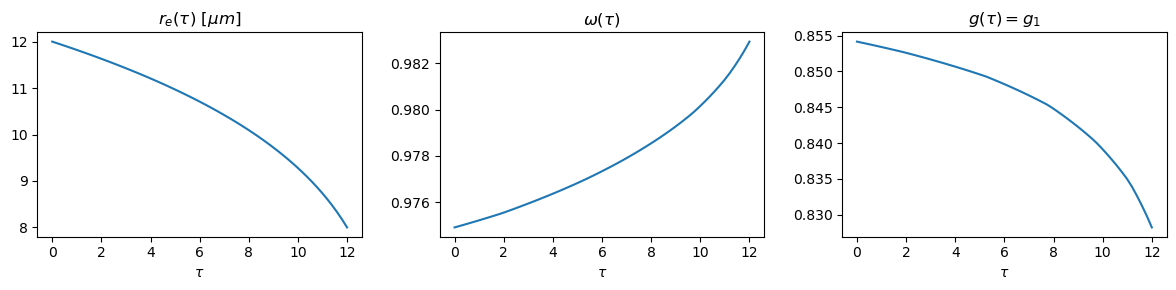

In [2]:
wavelength, v_eff = 2.13, 0.10           # MODIS band 7 (microns), gamma width

tau_bot = 12.0
NQuad, NLeg, NLeg_all = 16, 16, 32       # streams; NLeg_all > NLeg feeds delta-M / TMS
precomp = mie_legendre_precompute(max_nstop=512, NLeg=NLeg_all)

# Optics interpolation table r_e -> (omega, Leg_coeffs), built once (offline,
# high n_radii -> ripple-free). Full Mie inside the ODE never finishes compiling;
# the table makes the optics O(1) and keeps r_e -> (omega, Leg) differentiable
# (table-slope Jacobian). select_channel picks the (single) MODIS band exactly.
opt = select_channel(
    build_re_table([wavelength], 2.0, 25.0, 32, v_eff, precomp, n_radii=600), 0)

# Adiabatic r_e(tau): grows from base (tau=tau_bot) to top (tau=0). The adiabatic
# law in OPTICAL DEPTH is r_e ~ tau^(1/5): r_e**3 ~ LWC ~ height z, but the
# extinction ~ r_e**2 makes tau ~ z^(5/3), so r_e ~ tau^(1/5). We make r_e**5 affine
# in tau -> r_e stays >= re_base and dr_e/dtau is finite (no root cusp at base).
re_top, re_base = 12.0, 8.0              # microns (marine Sc: gentle 12->8 um growth)
def r_e_of_tau(tau, re_top=re_top, re_base=re_base):
    return (re_base ** 5 + (re_top ** 5 - re_base ** 5) * (1 - tau / tau_bot)) ** (1 / 5)

def optics(tau, re_top=re_top, re_base=re_base):
    return table_lookup(opt, r_e_of_tau(tau, re_top, re_base))

omega_func      = lambda tau: optics(tau)[0]
Leg_coeffs_func = lambda tau: optics(tau)[1]

tau_plot = jnp.linspace(0, tau_bot, 60)
fig, ax = plt.subplots(1, 3, figsize=(12, 3))
ax[0].plot(tau_plot, [r_e_of_tau(t) for t in tau_plot]); ax[0].set_title(r'$r_e(\tau)\ [\mu m]$')
ax[1].plot(tau_plot, [omega_func(t) for t in tau_plot]); ax[1].set_title(r'$\omega(\tau)$')
ax[2].plot(tau_plot, [Leg_coeffs_func(t)[1] for t in tau_plot]); ax[2].set_title(r'$g(\tau)=g_1$')
for a in ax: a.set_xlabel(r'$\tau$')
plt.tight_layout()

## 2. Forward model: ToA radiance

Solve, then interpolate to the satellite viewing geometry. This `forward` function — radiance as a function of the profile parameters — is the object we will both evaluate and differentiate.

In [3]:
mu0, I0, phi0 = 0.6, 1.0, 0.0           # solar geometry
mu_obs, phi_obs = 0.5, pi               # viewing geometry
BDRF = [0.05 / pi]                       # ocean surface

def forward(re_top, re_base):
    om  = lambda tau: optics(tau, re_top, re_base)[0]
    Leg = lambda tau: optics(tau, re_top, re_base)[1]
    mu_arr_pos, flux_up, u0, u_func, _ = pydisort_riccati_jax(
        tau_bot, om, Leg, NQuad, mu0, I0, phi0,
        tol=1e-3, BDRF_Fourier_modes=BDRF,                    # float32-safe production tol
        delta_M_scaling=True, NLeg_all=NLeg_all, NT_cor=True)  # forward-peak fix (OUTSTANDING A)
    return interpolate(u_func, mu_arr_pos)(mu_obs, phi_obs)

I_obs = forward(re_top, re_base)
print('ToA radiance at (mu_obs, phi_obs):', float(I_obs))

ToA radiance at (mu_obs, phi_obs): 0.27167636156082153


## 3. Retrieval Jacobian via autodiff

Because the whole chain is JAX-traceable, the sensitivity of the observed radiance to the profile parameters is a single `jax.grad` — no finite differences, no perturbing the solver. This $\partial I/\partial r_e$ is the building block of the retrieval's Gauss–Newton / optimal-estimation step.

*Parameters must enter through `omega_func`/`Leg_coeffs_func`; `tau_bot`, `mu0`, `NQuad` are validated in NumPy and are not differentiable. Finite-difference validation of these gradients lives in the float64 test suite (`pytest -m float64`); in float32 a bare FD is dominated by the solver's tolerance floor, so we don't reproduce it in this demonstration.*

In [4]:
dI_dre_top, dI_dre_base = jax.grad(forward, argnums=(0, 1))(re_top, re_base)
print('dI/d(r_e top)  =', float(dI_dre_top))
print('dI/d(r_e base) =', float(dI_dre_base))

dI/d(r_e top)  = 0.015204000286757946
dI/d(r_e base) = -0.00020430953009054065


## 4. Toward a multi-band retrieval

A real retrieval stacks several MODIS bands (0.645 µm constrains $\tau$, 2.13 µm constrains $r_e$) and minimises a cost $\;J(\boldsymbol\theta)=\sum_b \lVert I_b^{\text{obs}}-F_b(\boldsymbol\theta)\rVert^2 + \text{(prior)}$ over the $r_e(\tau)$ parameters $\boldsymbol\theta$.
 The gradient $\nabla_{\boldsymbol\theta} J$ is assembled from the per-band Jacobians above via `jax.grad`, and fed to an optimiser (`jaxopt`, `optax`, or a hand-rolled Gauss–Newton step). Stacking bands is just building the table at several wavelengths — `build_re_table([0.645, 1.64, 2.13], …)` and `select_channel` per band; a hyperspectral instrument instead builds on a dense, uniform $\lambda$ grid and `slice_wavelength`-interpolates to each channel.

**Performance & scope notes.** The forward model's cost is dominated by the number of adaptive Riccati steps (~35 for $\tau{=}30$); loosen `tol` in the retrieval loop and tighten only for the final fit. The default float32 is adequate against VOCALS measurement noise (10–20 %); enable `jax_enable_x64` for finite-difference gradient checks. Delta-M scaling + the Nakajima–Tanaka TMS correction are **enabled here** (`delta_M_scaling=True, NT_cor=True`, with `NLeg_all=32` untruncated moments) so the forward-peaked-Mie ToA radiance stays non-negative (see [`OUTSTANDING.md`](./OUTSTANDING.md) §A); the reverse-mode Jacobian is exact AD, its memory now bounded by the `lax.scan` over Fourier modes (§H).

## 5. A real VOCALS-REx profile (the retrieval *truth*)

We now retrieve $r_e(\tau)$ from a genuine VOCALS-REx marine-stratocumulus
penetration. `vocals_io` reads a C-130 flight (CDP probe, 1 Hz), finds clean
vertical in-cloud profiles, and returns each as $(\tau, r_e)$ with the
cloud-optical-depth integration $\tau(z)=\pi\!\int Q_{\rm ext}\,r_e^2 N_c\,dz$
from cloud top down. We start with a **thin** profile ($\tau_{\rm bot}\!\approx\!1.2$);
$\tau_{\rm bot}$ and the base radius $r_e(\tau_{\rm bot})$ are taken as **known**
(the two hardest quantities to retrieve in thick cloud — deferred).

RF11: tau_bot=1.21, r_e 5.8-8.7 um, n=20


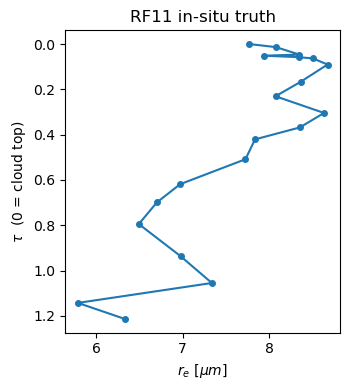

In [5]:
import jax
jax.clear_caches()   # free the intro cells' compiled executables before the (memory-heavy) retrieval

import vocals_io as vio
import retrieval_oe as roe
from miejax_lite import mie_legendre_precompute, build_re_table, select_channel

DATA = ('/home/jovyan/cloud_profile_retrieval/'
        'multispectral-retrieval-using-MODIS/VOCALS_REx_data')
truth = vio.pick_profile(vio.load_all_profiles(DATA), target_tau=1.0)
print(f'{truth.flight}: tau_bot={truth.tau_bot:.2f}, '
      f'r_e {truth.r_e.min():.1f}-{truth.r_e.max():.1f} um, n={truth.tau.size}')

fig, ax = plt.subplots(figsize=(3.6, 4))
ax.plot(truth.r_e, truth.tau, 'o-', ms=4)
ax.invert_yaxis()
ax.set_xlabel(r'$r_e\ [\mu m]$'); ax.set_ylabel(r'$\tau$  (0 = cloud top)')
ax.set_title(f'{truth.flight} in-situ truth')
plt.tight_layout()

In [6]:
# --- shared UQ-presentation helpers (used by the thin AND thick sections) ----
# Headline per-node "measurement vs prior" = the variance reduction
# 1 - S_hat_ii/Sa_ii: the fraction of each node's PRIOR uncertainty that the
# measurement removed. It answers "how much did the data tighten this node?".
# Two companions keep it honest: the panel-1 +/-1sigma bars are the ABSOLUTE
# precision (how the residual uncertainty grows with depth), and DOFS = tr(A)
# counts INDEPENDENT features -- which is less than the sum of the per-node
# reductions because the nodes are correlated (the measurement constrains them
# jointly, not independently).

def dofs_sentence(post, m):
    return (f"DOFS = {post.dofs:.2f}: from {m} radiances the measurement pins down "
            f"about {post.dofs:.1f} independent features of r_e(tau); the prior + its "
            f"smoothness fill in the rest. (Per node the measurement removes most of "
            f"the prior uncertainty -- the bars -- but the nodes are correlated, so "
            f"that does not add up to one independent piece each.)")

def plot_uq(fwd, res, post, truth, title=""):
    """Three clarity-first panels: retrieved-vs-truth (with +/-1sigma) | per-node
    fraction of prior uncertainty removed by the measurement | averaging kernels."""
    tau_d = np.linspace(0.0, fwd.tau_bot, 200)
    truth_at = np.interp(res.tau_nodes, truth.tau, truth.r_e)
    fig, ax = plt.subplots(1, 3, figsize=(13, 4))

    ax[0].plot(truth.r_e, truth.tau, '-', color='k', alpha=0.4, label='truth (in situ)')
    ax[0].plot(fwd.profile(res.x_a, res.tau_nodes, tau_d), tau_d, '--', color='C1',
               alpha=0.6, label='prior (adiabatic)')
    ax[0].plot(fwd.profile(res.x, res.tau_nodes, tau_d), tau_d, '-', color='C0',
               lw=2, label='retrieved')
    ax[0].errorbar(res.x, res.tau_nodes, xerr=post.error, fmt='o', color='C0',
                   capsize=3, label=r'nodes $\pm1\sigma$')
    ax[0].plot(truth.r_base, fwd.tau_bot, 'o', color='red', ms=9, zorder=5,
               label='known base')
    ax[0].invert_yaxis(); ax[0].set_xlabel(r'$r_e\ [\mu m]$'); ax[0].set_ylabel(r'$\tau$')
    ax[0].legend(fontsize=8); ax[0].set_title('retrieved vs in-situ truth')

    meas = np.clip(post.data_fraction, 0.0, 1.0)       # 1 - S_hat_ii/Sa_ii
    yld = np.arange(res.tau_nodes.size)
    ax[1].barh(yld, meas, color='C0', label='from measurement')
    ax[1].barh(yld, 1 - meas, left=meas, color='0.82', label='from prior')
    for i, f in enumerate(meas):
        ax[1].text(0.5, i, f'{f*100:.0f}% meas / {(1-f)*100:.0f}% prior',
                   va='center', ha='center', fontsize=8)
    ax[1].set_yticks(yld); ax[1].set_yticklabels([f'{t:.2f}' for t in res.tau_nodes])
    ax[1].invert_yaxis(); ax[1].set_xlim(0, 1)
    ax[1].set_xlabel('fraction of prior uncertainty removed')
    ax[1].set_ylabel(r'node $\tau$'); ax[1].legend(fontsize=8, loc='lower right')
    ax[1].set_title('where each node value comes from')

    for i in range(res.tau_nodes.size):
        ax[2].plot(post.A[i], res.tau_nodes, 'o-',
                   label=fr'$\tau$={res.tau_nodes[i]:.2f}')
    ax[2].invert_yaxis()
    ax[2].set_xlabel('averaging-kernel row'); ax[2].set_ylabel(r'$\tau$')
    ax[2].legend(fontsize=7); ax[2].set_title('averaging kernels (expert)')
    fig.suptitle(title, fontsize=11); plt.tight_layout()
    return truth_at

## 6. Multi-band, multi-angle forward model

The observation stacks bidirectional reflectance $R=\pi u/(\mu_0 I_0)$ over an
**absorption ladder** of bands $\times$ **view angles**. The bands (1.24, 2.13 µm)
span weak$\to$strong water absorption, so their weighting functions peak at
different depths (Platnick 2000); the multiple view angles (nadir to ~60°, within
the PACE/SPEXone envelope and the back-scatter regime away from the forward
aureole) add vertical information — our lever beyond the mostly-nadir MODIS
literature.

Two forward-model settings matter (see [`OUTSTANDING.md`](./OUTSTANDING.md) §A′, §H):
**`NLeg_all=128`** — the Nakajima–Tanaka single-scatter correction reconstructs the
phase function as a truncated Legendre sum, and a Mie *cloud* needs ~60+ moments
(32 gives a Gibbs-oscillating $p_{\rm full}$ that wrecks the thin-cloud, single-
scatter-dominated off-nadir radiance). **`NFourier`** is now a *ceiling*, not a fixed
workaround: the azimuthal modes run under a single `lax.scan` (the mode body compiles
**once** — $O(1)$ in mode count — which lifted the old reverse-mode-Jacobian memory
ceiling, §H), and the per-band count is then chosen from the **measurement noise** by
`roe.select_num_modes`, which keeps only modes whose ToA-reflectance contribution
exceeds $\sim\!\tfrac13$ of the observation $\sigma_\varepsilon$. For a *bright* cloud
at this radiometric floor that keeps all 8 post-delta-M modes; it trims automatically
for dimmer scenes. (This replaces the old in-solver relative-Cauchy test, which
judged convergence against the *signal* rather than the noise and saturated at low
signal.)

In [7]:
bands = [1.24, 2.13]                         # weak -> strong absorption ladder
NQuad, NLeg_all, v_eff = 16, 128, 0.10
precomp = mie_legendre_precompute(max_nstop=512, NLeg=NLeg_all)
table = build_re_table(bands, 2.0, 25.0, 32, v_eff, precomp, n_radii=600)
opt_bands = [select_channel(table, i) for i in range(len(bands))]

mu0, I0, phi0 = 0.6, 1.0, 0.0
view_mu = np.array([0.90, 0.65, 0.50])      # ~25, 50, 60 deg view zenith
view_phi = np.array([pi, pi, pi])           # principal plane, back-scatter
BDRF = [[0.05 / pi]] * len(bands)           # dark ocean

fwd = roe.RetrievalForward(
    opt_bands, NQuad=NQuad, mu0=mu0, I0=I0, phi0=phi0,
    tau_bot=truth.tau_bot, r_base=truth.r_base,
    view_mu=view_mu, view_phi=view_phi, BDRF_bands=BDRF)

# Choose the per-band azimuthal mode count from the noise floor (S_eps selector),
# up front, so the forward compiles once at the chosen K. Reference state = the
# adiabatic first guess on a coarse grid; representative ~0.5% radiometric noise.
tau_ref = np.linspace(0.0, truth.tau_bot, 5)[:-1]
x_ref, _ = roe.make_adiabatic_prior(tau_ref, truth.tau_bot, truth.r_base,
                                    r_top_prior=truth.r_top)
K = roe.select_num_modes(fwd, x_ref, tau_ref, (0.005 ** 2) * np.eye(fwd.m))
print(f'{len(bands)} bands x {view_mu.size} angles = {fwd.m} observations; '
      f'NLeg_all={NLeg_all}, S_eps-selected modes K={K}')

2 bands x 3 angles = 6 observations; NLeg_all=128, S_eps-selected modes K=[8, 8]


## 7. OSSE observation $y = F(x_{\rm true})$

We generate a **noiseless** synthetic observation by running the forward model on
the dense in-situ truth profile (an Observing System Simulation Experiment). Noise
is deferred by design — the pipeline is being built toward operational PACE data;
the assumed radiometric error $S_\varepsilon$ still weights the cost and sets the
posterior uncertainty.

In [8]:
y = roe.osse_observation(fwd, truth.tau, truth.r_e)   # noiseless
print('observation y = pi u/(mu0 I0)   [rows = bands, cols = view angles]')
print(np.round(y.reshape(len(bands), view_mu.size), 4))
assert np.all(y > 0), 'unphysical (negative) reflectance'

observation y = pi u/(mu0 I0)   [rows = bands, cols = view angles]
[[0.1094 0.246  0.2467]
 [0.1061 0.2172 0.2793]]


## 8. Retrieval grid: a QRCP-trimmed subset of the adaptive ODE grid

The retrieval grid is **not** prescribed a-priori. The L-stable solver places its
adaptive $\tau$-steps by genuine variation of the Riccati state, making that grid a
trustworthy *superset* of the retrieval-informative points (`DESIGN_DECISIONS.md`
§3). We form the ToA sensitivity $\partial y/\partial r_e(\tau_j)$ on that pool by
autodiff and rank the nodes by independent information with QR-with-column-pivoting,
keeping a small subset (here $k=4$, cloud top always included). The deep BoA steps
— densest but least informative — are pruned by sensitivity.

In [9]:
tau_coarse = np.linspace(0.0, truth.tau_bot, 6)[:-1]      # adiabatic first guess grid
x0, _ = roe.make_adiabatic_prior(tau_coarse, truth.tau_bot, truth.r_base,
                                 r_top_prior=truth.r_top)
k_active = 4
tau_grid, re_grid, info = roe.select_retrieval_grid(fwd, x0, tau_coarse, k_active)
print(f'ODE pool: {info["tau_pool"].size} nodes  ->  QRCP-selected {k_active}: '
      f'tau = {np.round(tau_grid, 3)}')

ODE pool: 20 nodes  ->  QRCP-selected 4: tau = [0.    0.037 0.315 0.651]


## 9. Prior: adiabatic mean + Bayesian–Tikhonov covariance

The prior is the **adiabatic** $r_e^5$-linear profile (known base $\to$ prior top)
with a **correlated** Gaussian covariance
$S_a[i,j]=\sigma_i\sigma_j\exp(-|\tau_i-\tau_j|/\ell)$: depth-increasing $\sigma$
(top tight ~3 µm, base loose ~10 µm — the weighting-function argument that deep
$r_e$ is poorly constrained), and an off-diagonal correlation length $\ell$ that
*is* the Bayesian–Tikhonov smoothness term. The interface is **pluggable** — a
data-learned prior (VOCALS ensemble / EOF) would slot in with the same signature.

In [10]:
prior_builder = lambda tn: roe.make_adiabatic_prior(
    tn, truth.tau_bot, truth.r_base, r_top_prior=truth.r_top,
    sigma_top=3.0, sigma_base=10.0)
x_a, Sa = prior_builder(tau_grid)

# observation error covariance: assumed ~3% radiometric (floor for tiny R)
sigma_obs = 0.03 * np.maximum(np.abs(y), 0.02)
Se = np.diag(sigma_obs ** 2)
print('prior  x_a   =', np.round(x_a, 2))
print('prior  sigma =', np.round(np.sqrt(np.diag(Sa)), 1), 'um (top->base)')

prior  x_a   = [7.77 7.74 7.49 7.14]
prior  sigma = [3.  3.2 4.8 6.8] um (top->base)


## 10. Optimal estimation with lagged re-meshing

Rodgers Gauss–Newton minimises
$J(x)=\tfrac12\|y-F(x)\|^2_{S_\varepsilon^{-1}}+\tfrac12\|x-x_a\|^2_{S_a^{-1}}$.
The Jacobian $K=\partial y/\partial x$ is exact reverse-mode autodiff through the
jitted solver (no finite differences). An **outer loop** re-selects the retrieval
grid by QRCP at the *current* estimate and re-maps the state and prior onto the new
nodes — correcting the first-guess node placement. Because the node *count* is fixed,
relocating them is recompile-free r-refinement.

In [11]:
res = roe.gauss_newton_oe(
    fwd, y, tau_grid, x_a, Sa, Se, n_iter=10, lm=1e-2, xtol=2e-3,
    n_outer=2, k_active=k_active, prior_builder=prior_builder)

truth_at = np.interp(res.tau_nodes, truth.tau, truth.r_e)
print(f'converged={res.converged}, '
      f'cost {res.cost_history[0]:.2e} -> {res.cost_history[-1]:.2e}, '
      f'||y-F|| = {np.linalg.norm(res.y - res.Fx):.2e}')
print(f'final grid tau = {np.round(res.tau_nodes, 3)}')
print(f'  retrieved = {np.round(res.x, 2)}')
print(f'  truth     = {np.round(truth_at, 2)}')
print(f'  prior x_a = {np.round(res.x_a, 2)}')

converged=True, cost 8.73e-01 -> 3.69e-02, ||y-F|| = 8.69e-04
final grid tau = [0.    0.313 0.519 0.765]
  retrieved = [8.32 8.41 7.69 6.91]
  truth     = [7.77 8.6  7.65 6.56]
  prior x_a = [7.77 7.5  7.29 7.01]


## 11. Uncertainty quantification — the deliverable

The posterior covariance $\hat S=(K^{\!\top}S_\varepsilon^{-1}K+S_a^{-1})^{-1}$ gives
the retrieval error $\sqrt{\mathrm{diag}\,\hat S}$ — the $\pm1\sigma$ bars, the
**absolute** precision per node (which degrades with depth). The **averaging kernel**
$A=\hat S\,K^{\!\top}S_\varepsilon^{-1}K$ shows where in $\tau$ each retrieved level
draws its information, and $\mathrm{DOFS}=\mathrm{tr}\,A$ counts the independent pieces
of profile information.

The middle panel below is the headline: for each node, the **fraction of its prior
uncertainty the measurement removed**, $1-\hat S_{ii}/S_{a,ii}$ — a per-node "%
measurement / % prior" bar, no curve-reading required (the averaging-kernel curves are
the expert third panel). **Plain-language DOFS:** it is the *continuous* generalisation
of "number of independent measurements" — $\mathrm{DOFS}\approx2$ means the radiances
pin down about two independent features of the profile, **not** "2 of the 4 nodes."
These two numbers can look like they disagree — a node can read 90% "from measurement"
while DOFS is only ~2 — and that is the point: the node values are **correlated**, so
the measurement constrains them *jointly*. Each node's marginal uncertainty drops a lot,
but only ~DOFS *independent* combinations are actually determined; the absolute $\pm1\sigma$
bars are the honest precision.

*The retrieved/prior curves are drawn with `fwd.profile()` — the **same
parameterisation the forward model integrated** (the `_re_of_tau` lever in
`retrieval_oe`), extended to the assumed-known base (red), so the curve mirrors $F(x)$
exactly. The default class is **$r_e^5$-linear (adiabatic)** — the adiabatic law in
optical depth is $r_e\propto\tau^{1/5}$ ($r_e^3\propto\,$LWC is the geometric-height
law); **linear** (impute-nothing) is the recorded alternative for the §B′ model
comparison. Flipping the lever changes the retrieval and this plot consistently.*

DOFS = 2.49: from 6 radiances the measurement pins down about 2.5 independent features of r_e(tau); the prior + its smoothness fill in the rest. (Per node the measurement removes most of the prior uncertainty -- the bars -- but the nodes are correlated, so that does not add up to one independent piece each.)
retrieval 1-sigma error = [1.84 1.51 1.94 1.45] um  (per node, top->base)


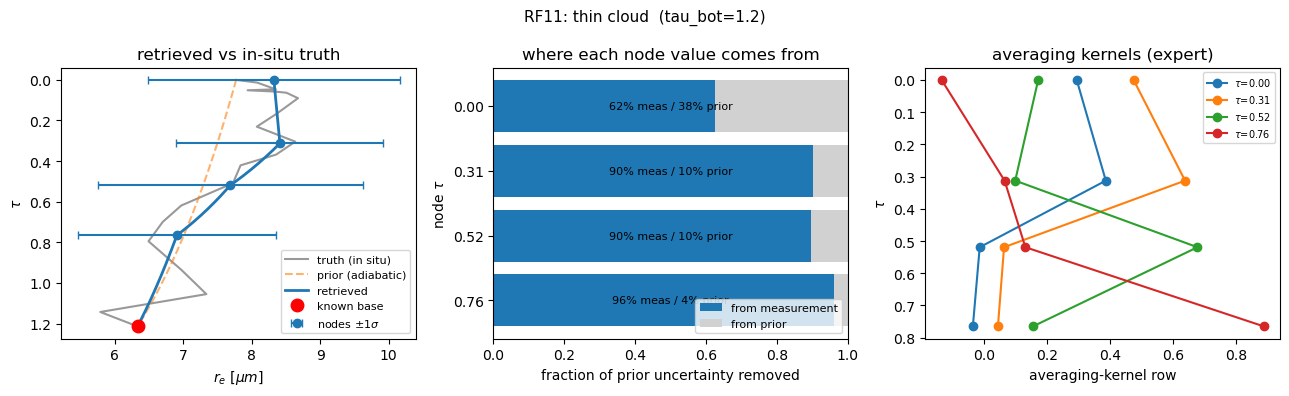

In [12]:
post = roe.posterior_diagnostics(res.K, res.Sa, res.Se)
print(dofs_sentence(post, fwd.m))
print('retrieval 1-sigma error =', np.round(post.error, 2), 'um  (per node, top->base)')

# plot_uq draws all three panels via fwd.profile() (the forward's own r_e(tau)),
# so the displayed curve mirrors F(x); the middle panel is the headline split.
_ = plot_uq(fwd, res, post, truth,
            title=f'{truth.flight}: thin cloud  (tau_bot={truth.tau_bot:.1f})')

## 12. A thick, non-adiabatic cloud ($\tau\approx23$): the measurement earns its keep

The thin case above was *near-adiabatic*, so the adiabatic prior nearly sat at the
answer and the measurement mostly **confirmed** it. We now retrieve a genuinely
**non-adiabatic** thick profile — VOCALS-REx **RF03** ($\tau_{\rm bot}\!\approx\!23$),
whose upper-cloud $r_e$ runs $\sim$1.5–2 µm *below* the adiabatic prior (a
sharper-than-adiabatic drop just under cloud top). Three things change versus thin:

1. **The measurement must correct the prior**, not just confirm it — it pulls every
   node *down* off the over-high adiabatic prior toward the lower truth, and the cost
   drops by ~2 orders. (The recovery is not perfect: the smooth $r_e^5$ class can't
   reproduce a sharp sub-optical-depth in-situ wiggle, so the near-top node is the one
   place the retrieval visibly lags the truth.)
2. **Precision degrades with depth.** The retrievable nodes concentrate in the
   upper/middle cloud (the deepest sits near $\tau\!\approx\!13$ of 23; below that is the
   fixed base anchor + prior), and the absolute $\pm1\sigma$ error grows steadily toward
   the base. It does *not* collapse to the prior, though: the loose deep prior leaves
   room, and each deep node's wide $r_e^5$ segment gives it leverage on the *visible*
   upper cloud — so the measurement still tightens it. The depth signal lives in the
   **absolute** $\pm1\sigma$ error, not in the fractional bar.
3. We add a third band (**1.64 µm**) to the absorption ladder for a little more vertical
   leverage.

Everything else is reused unchanged: the $r_e^5$-linear class, the QRCP grid, the
adiabatic Bayesian–Tikhonov prior, and the $S_\varepsilon$ mode selector. (A thick
cloud is *brighter*, so at a fixed radiometric floor the selector keeps more azimuthal
modes than a dim thin cloud — the post-`scan` solver runs them without the old memory
ceiling.) We select the grid **once** here ($n_{\rm outer}\!=\!1$): with only
$\sim$2–3 degrees of freedom spread across the (correlated) nodes, re-pivoting QRCP at a
moved estimate would reshuffle the surplus deep nodes without changing the profile — the
thin section already demonstrated the lagged re-mesh, so we keep a single well-spread
grid here.

In [13]:
import jax
jax.clear_caches()   # free the thin retrieval's executables before the thicker solve

thick = vio.pick_profile(
    [p for p in vio.load_all_profiles(DATA) if p.flight == 'RF03'], target_tau=23.3)
print(f'{thick.flight}: tau_bot={thick.tau_bot:.1f}, '
      f'r_e {thick.r_e.min():.1f}-{thick.r_e.max():.1f} um, n={thick.tau.size}')

bandsT = [1.24, 1.64, 2.13]                   # weak -> strong absorption ladder (+1.64)
opt_bandsT = [select_channel(build_re_table(bandsT, 2.0, 25.0, 32, v_eff, precomp,
                                            n_radii=600), i)
              for i in range(len(bandsT))]
BDRFt = [[0.05 / pi]] * len(bandsT)           # dark ocean, per band

fwdT = roe.RetrievalForward(
    opt_bandsT, NQuad=NQuad, mu0=mu0, I0=I0, phi0=phi0,
    tau_bot=thick.tau_bot, r_base=thick.r_base,
    view_mu=view_mu, view_phi=view_phi, BDRF_bands=BDRFt, NLeg_all=NLeg_all)

# S_eps mode selection at the adiabatic first guess, then OSSE + QRCP grid (k=5:
# a thick cloud supports a few more nodes than the thin case).
tau_refT = np.linspace(0.0, thick.tau_bot, 6)[:-1]
x_refT, _ = roe.make_adiabatic_prior(tau_refT, thick.tau_bot, thick.r_base,
                                     r_top_prior=thick.r_top)
KT = roe.select_num_modes(fwdT, x_refT, tau_refT, (0.005 ** 2) * np.eye(fwdT.m))
yT = roe.osse_observation(fwdT, thick.tau, thick.r_e)   # noiseless OSSE
assert np.all(yT > 0), 'unphysical (negative) reflectance'
k_activeT = 5
tau_gridT, _, _ = roe.select_retrieval_grid(fwdT, x_refT, tau_refT, k_activeT)
print(f'{len(bandsT)} bands x {view_mu.size} angles = {fwdT.m} obs; modes K={KT}')
print(f'QRCP-selected {k_activeT} nodes: tau = {np.round(tau_gridT, 2)}  '
      f'(of tau_bot={thick.tau_bot:.1f})')

RF03: tau_bot=23.3, r_e 5.5-11.4 um, n=109


3 bands x 3 angles = 9 obs; modes K=[8, 8, 8]
QRCP-selected 5 nodes: tau = [ 0.    1.2   3.51  6.63 12.95]  (of tau_bot=23.3)


cost 1.24e+01 -> 2.64e-01, ||y-F|| = 1.22e-02   (measurement corrects the prior)
  retrieved = [10.89 10.32  9.33  8.58  8.38]
  truth     = [11.41  9.28  9.62  8.81  8.04]
  prior x_a = [11.41 11.3  11.06 10.72  9.83]
DOFS = 2.36: from 9 radiances the measurement pins down about 2.4 independent features of r_e(tau); the prior + its smoothness fill in the rest. (Per node the measurement removes most of the prior uncertainty -- the bars -- but the nodes are correlated, so that does not add up to one independent piece each.)


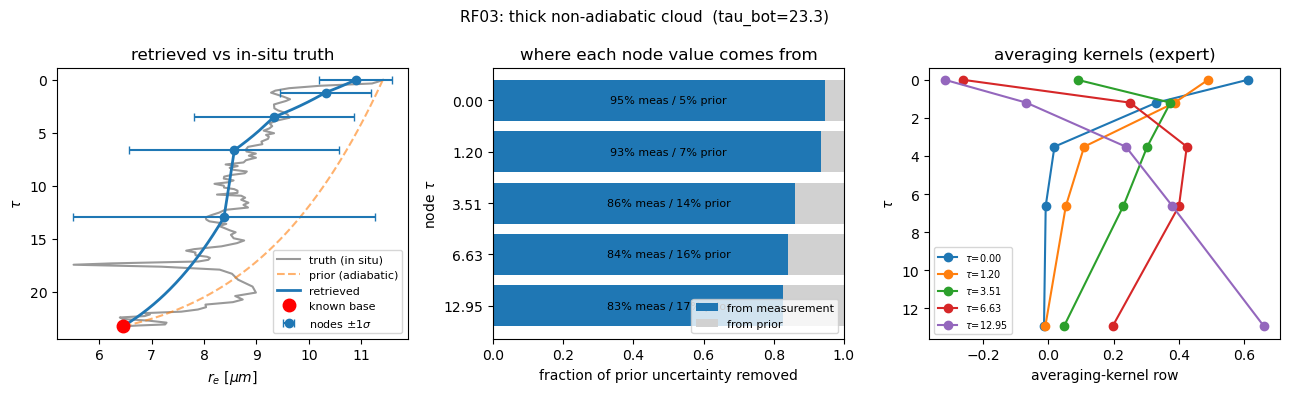

In [14]:
prior_builderT = lambda tn: roe.make_adiabatic_prior(
    tn, thick.tau_bot, thick.r_base, r_top_prior=thick.r_top,
    sigma_top=3.0, sigma_base=10.0)
x_aT, SaT = prior_builderT(tau_gridT)
SeT = np.diag((0.03 * np.maximum(np.abs(yT), 0.02)) ** 2)   # ~3% radiometric + floor

# Select the grid once (n_outer=1): the thin section already demonstrated the lagged
# re-mesh; here a single well-spread QRCP grid keeps the (poorly-constrained) deep
# nodes legible. xtol=5e-3 ~ 0.05 um is the meaningful step scale (errors ~0.5-3 um).
resT = roe.gauss_newton_oe(fwdT, yT, tau_gridT, x_aT, SaT, SeT,
                           n_iter=15, lm=1e-2, xtol=5e-3, n_outer=1)
postT = roe.posterior_diagnostics(resT.K, resT.Sa, resT.Se)

truth_atT = np.interp(resT.tau_nodes, thick.tau, thick.r_e)
print(f'cost {resT.cost_history[0]:.2e} -> {resT.cost_history[-1]:.2e}, '
      f'||y-F|| = {np.linalg.norm(resT.y - resT.Fx):.2e}   (measurement corrects the prior)')
print(f'  retrieved = {np.round(resT.x, 2)}')
print(f'  truth     = {np.round(truth_atT, 2)}')
print(f'  prior x_a = {np.round(resT.x_a, 2)}')
print(dofs_sentence(postT, fwdT.m))
_ = plot_uq(fwdT, resT, postT, thick,
            title=f'{thick.flight}: thick non-adiabatic cloud  (tau_bot={thick.tau_bot:.1f})')

## 13. Notes and next steps

- **Deliverable 1 (UQ)** is the per-node measurement-vs-prior split + averaging
  kernels above (both clouds): they quantify, under the adiabatic prior, exactly which
  part of $r_e(\tau)$ the multi-band / multi-angle measurement constrains and which is
  prior-dominated.
- **Deliverable 2** is the recovery of real VOCALS-REx profiles — a **thin**
  near-adiabatic cloud ($\tau\!\approx\!1$), where the adiabatic prior already nearly
  suffices and the measurement *confirms* it, and a **thick non-adiabatic** cloud
  ($\tau\!\approx\!23$, §12), where the measurement *corrects* the prior in the upper
  cloud (cost drops ~2 orders) while the deep cloud stays prior-dominated (the error
  grows and $A_{ii}$ shrinks with depth).
- **Forward model** (tracked in [`OUTSTANDING.md`](./OUTSTANDING.md)): the azimuthal
  Fourier modes now run under a single `lax.scan` — the mode body compiles **once**
  (§H, resolved), which lifted the NQuad / reverse-mode-Jacobian memory ceiling — with
  the noise-aware `select_num_modes` setting the per-band mode count. Still-open levers:
  the $r_e(\tau)$ function-class (§B′) and a thin-cloud Mie off-nadir plausibility test
  (§A′); the prior interface is ready for a learned (ensemble / EOF) prior.
- **Operational next step:** scale to the full VOCALS-REx column ensemble
  (`vmap`-over-columns $\times$ `scan`-over-modes) toward PACE.